# Séries Chronologiques  Méthode de Box-Jenkins
## Série : Ventes mensuelles de voitures au Québec (1960–1968)

**Objectif** : Construire un modèle SARIMA permettant de prévoir les ventes de voitures.

### Plan du notebook
1. Chargement et visualisation des données  
2. Division apprentissage / validation  
3. Analyse qualitative (tendance, saisonnalité)  
4. Test de stationnarité  
5. Corrélogrammes ACF et PACF  
6. Méthode de Box-Jenkins (identification, estimation, validation)  
7. Prévision  
8. Évaluation des performances


## Étape 1: Chargement des données et visualisation

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [36]:
# Chargement des données
df = pd.read_csv("car_sales.csv")
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)
df.index.freq = "MS"  

print("Période  :", df.index[0].strftime("%B %Y"), "→", df.index[-1].strftime("%B %Y"))
print("Nb observations :", len(df))
print("Statistiques descriptives :")
print(df.describe().round(0))

Période  : January 1960 → December 1968
Nb observations : 108
Statistiques descriptives :
         Sales
count    108.0
mean   15396.0
std     5452.0
min     6550.0
25%    11300.0
50%    14494.0
75%    18152.0
max    29500.0


In [37]:
df.head(12)

,Sales
Month,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587
1960-06-01,13791
1960-07-01,9498
1960-08-01,8251
1960-09-01,7049


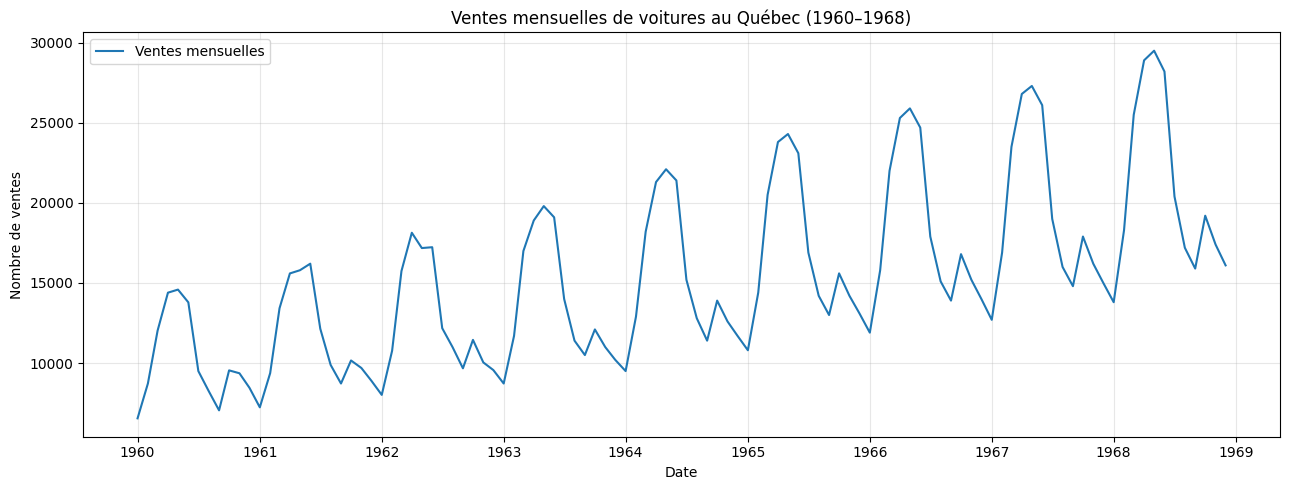

La série présente une tendance croissante et une saisonnalité annuelle marquée.


In [38]:
# Visualisation de la série
fig, ax = plt.subplots()
ax.plot(df.index, df["Sales"], label="Ventes mensuelles")
ax.set_title("Ventes mensuelles de voitures au Québec (1960–1968)")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de ventes")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.legend()
plt.tight_layout()
plt.show()
print("La série présente une tendance croissante et une saisonnalité annuelle marquée.")


## Étape 2: Division apprentissage / validation
On réserve les **20 % dernières observations (2 dernières années, soit 24 mois)** pour la validation.


Apprentissage : Jan 1960 → Dec 1966 (84 obs.)
Validation    : Jan 1967  → Dec 1968  (24 obs.)


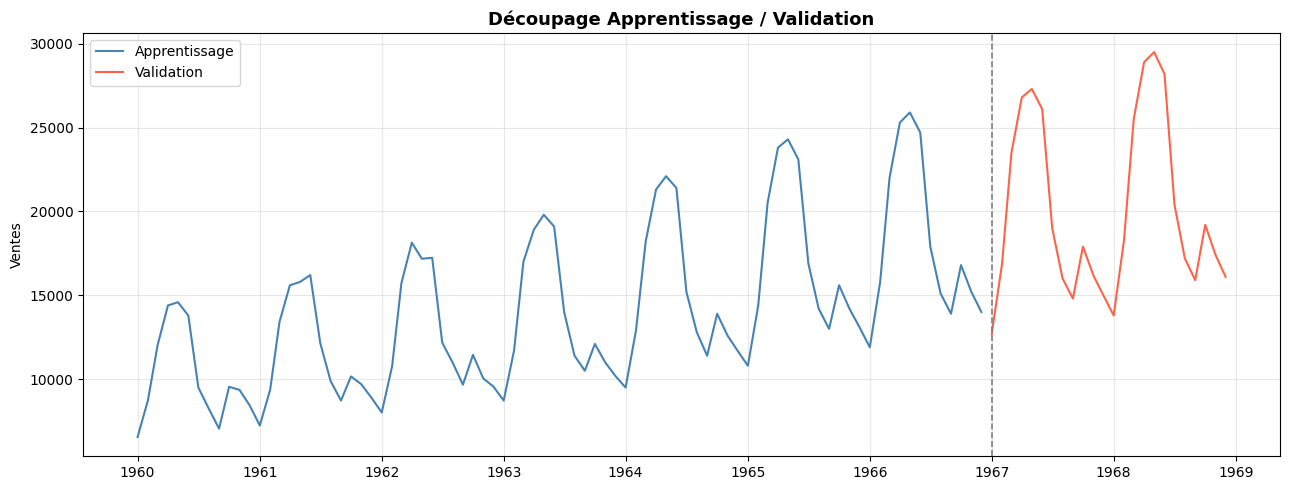

In [39]:
n_test = 24   # 2 années × 12 mois
train = df.iloc[:-n_test]
test  = df.iloc[-n_test:]

print(f"Apprentissage : {train.index[0].strftime('%b %Y')} → {train.index[-1].strftime('%b %Y')} ({len(train)} obs.)")
print(f"Validation    : {test.index[0].strftime('%b %Y')}  → {test.index[-1].strftime('%b %Y')}  ({len(test)} obs.)")

fig, ax = plt.subplots()
ax.plot(train.index, train["Sales"], color="steelblue", label="Apprentissage")
ax.plot(test.index,  test["Sales"],  color="tomato",    label="Validation")
ax.axvline(test.index[0], color="gray", linestyle="--", linewidth=1.2)
ax.set_title("Découpage Apprentissage / Validation", fontsize=13, fontweight="bold")
ax.set_ylabel("Ventes")
plt.legend()
plt.tight_layout()
plt.show()


## Étape 3: Analyse qualitative de la série
On examine visuellement la tendance, la saisonnalité et le résidu via une décomposition.


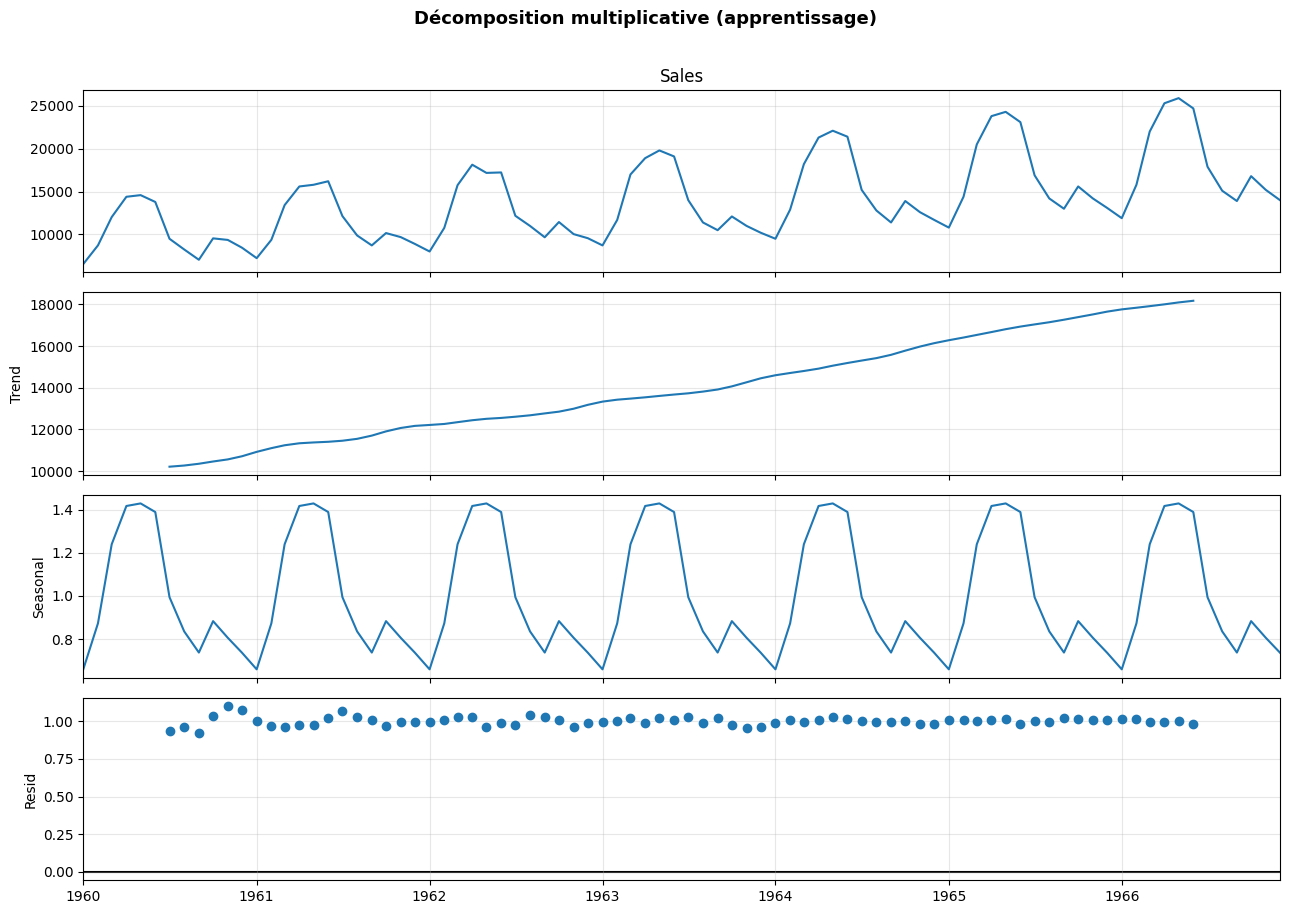

In [40]:
# Décomposition de la série 
# Modèle multiplicatif car l'amplitude saisonnière croît avec le niveau
decomposition = seasonal_decompose(train["Sales"], model="multiplicative", period=12)

fig = decomposition.plot()
fig.set_size_inches(13, 9)
fig.suptitle("Décomposition multiplicative (apprentissage)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()



Interprétation :
  - Tendance  : croissance régulière des ventes sur la période.
  - Saisonnalité : pic printanier (avril-mai), creux hivernal (jan-fév).
  - Résidu : fluctuations aléatoires autour de 1 => modèle correct.

#### Visualisation de la saisonnalité par mois

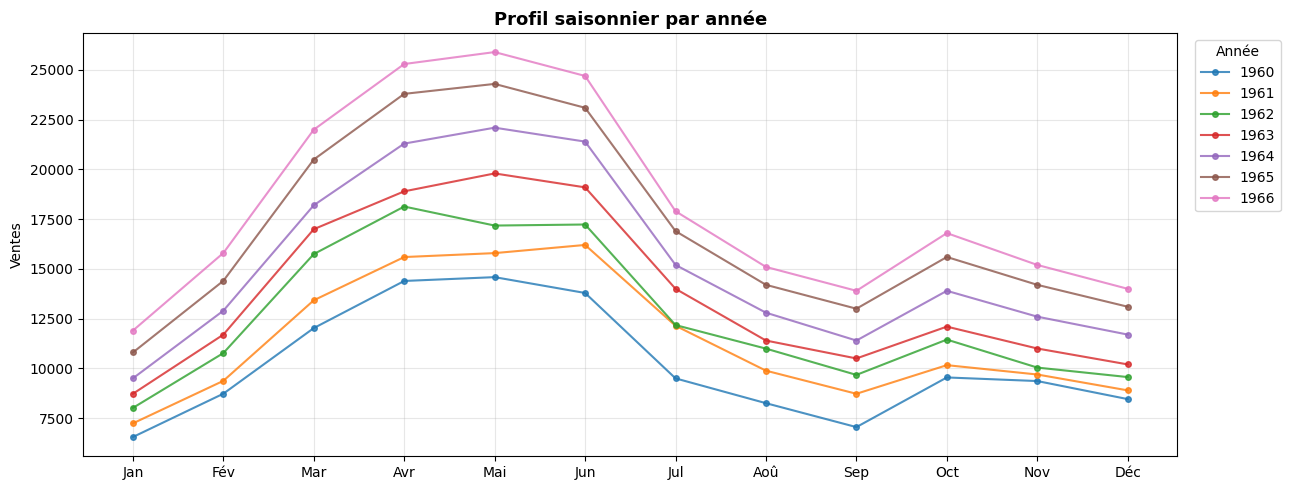

In [41]:

train_m = train.copy()
train_m["Mois"]  = train_m.index.month
train_m["Annee"] = train_m.index.year

pivot = train_m.pivot(index="Mois", columns="Annee", values="Sales")
mois_labels = ["Jan","Fév","Mar","Avr","Mai","Jun",
               "Jul","Aoû","Sep","Oct","Nov","Déc"]

fig, ax = plt.subplots()
for col in pivot.columns:
    ax.plot(range(1, 13), pivot[col], marker="o", markersize=4, label=str(col), alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_title("Profil saisonnier par année", fontsize=13, fontweight="bold")
ax.set_ylabel("Ventes")
plt.legend(title="Année", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Étape 4: Test de stationnarité
On applique le **test ADF** (Augmented Dickey-Fuller) et le **test KPSS** sur la série brute, puis après transformation logarithmique et différenciation.


In [42]:
# Fonction utilitaire 
def test_stationnarite(serie, label=""):
    adf_res  = adfuller(serie.dropna(), autolag="AIC")
    kpss_res = kpss(serie.dropna(), regression="c", nlags="auto")
    
    print(f" Série : {label}")
    print(f"{'─'*55}")
    print(f" ADF  — stat={adf_res[0]:.4f}  p={adf_res[1]:.4f}  ", end="")
    print("Stationnaire" if adf_res[1] < 0.05 else "Non stationnaire")
    print(f" KPSS — stat={kpss_res[0]:.4f}  p={kpss_res[1]:.4f}  ", end="")
    print("Stationnaire" if kpss_res[1] > 0.05 else "Non stationnaire")
    print()

# Série brute
serie_brute = train["Sales"]
test_stationnarite(serie_brute, "Série brute")

# Log-transformation
serie_log = np.log(serie_brute)
test_stationnarite(serie_log, "log(Ventes)")

# Différenciation simple (d=1)
serie_diff1 = serie_log.diff(1)
test_stationnarite(serie_diff1, "log(Ventes) — diff d=1")

# Différenciation saisonnière (D=1, s=12)
serie_diff_s = serie_log.diff(12)
test_stationnarite(serie_diff_s, "log(Ventes) — diff saisonnière D=1")

# Différenciation double (d=1 + D=1)
serie_stationnaire = serie_log.diff(1).diff(12)
test_stationnarite(serie_stationnaire, "log(Ventes) — d=1 + D=1")


 Série : Série brute
───────────────────────────────────────────────────────
 ADF  — stat=0.6435  p=0.9886  Non stationnaire
 KPSS — stat=0.8558  p=0.0100  Non stationnaire

 Série : log(Ventes)
───────────────────────────────────────────────────────
 ADF  — stat=-1.0958  p=0.7168  Non stationnaire
 KPSS — stat=0.9327  p=0.0100  Non stationnaire

 Série : log(Ventes) — diff d=1
───────────────────────────────────────────────────────
 ADF  — stat=-4.4701  p=0.0002  Stationnaire
 KPSS — stat=0.0382  p=0.1000  Stationnaire

 Série : log(Ventes) — diff saisonnière D=1
───────────────────────────────────────────────────────
 ADF  — stat=-1.8754  p=0.3437  Non stationnaire
 KPSS — stat=0.1916  p=0.1000  Stationnaire

 Série : log(Ventes) — d=1 + D=1
───────────────────────────────────────────────────────
 ADF  — stat=-3.4670  p=0.0089  Stationnaire
 KPSS — stat=0.0203  p=0.1000  Stationnaire



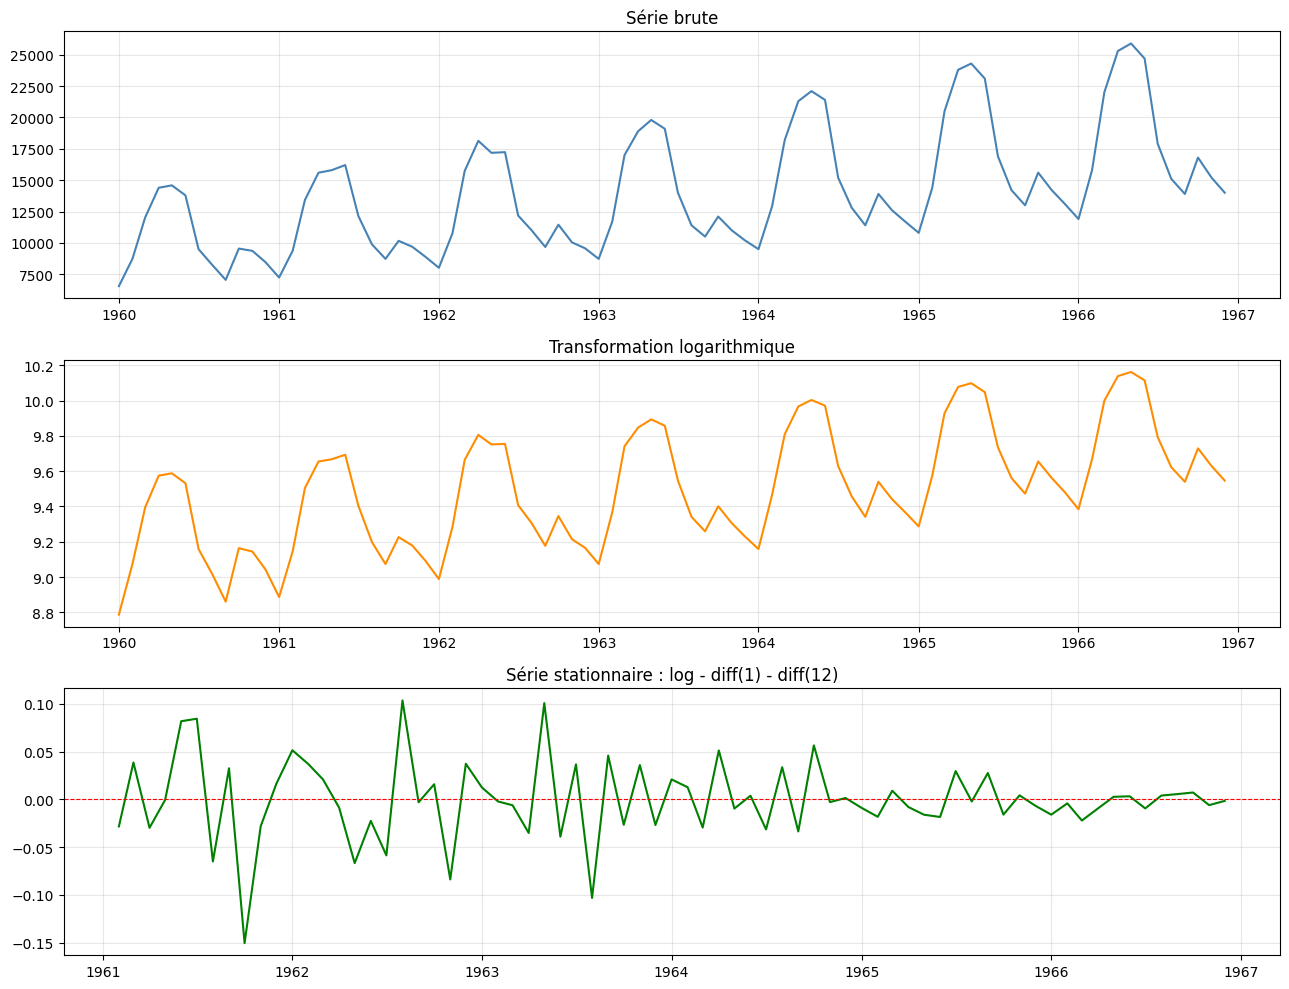

In [43]:
# Visualisation des transformations 
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(serie_brute, color="steelblue")
axes[0].set_title("Série brute")

axes[1].plot(serie_log, color="darkorange")
axes[1].set_title("Transformation logarithmique")

axes[2].plot(serie_stationnaire, color="green")
axes[2].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[2].set_title("Série stationnaire : log - diff(1) - diff(12)")

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Étape 5: Corrélogrammes ACF et PACF
On trace l'autocorrélation simple (ACF) et partielle (PACF) sur la série stationnaire pour un décalage K ≥ 36, afin d'identifier les ordres p, q, P, Q du modèle SARIMA.


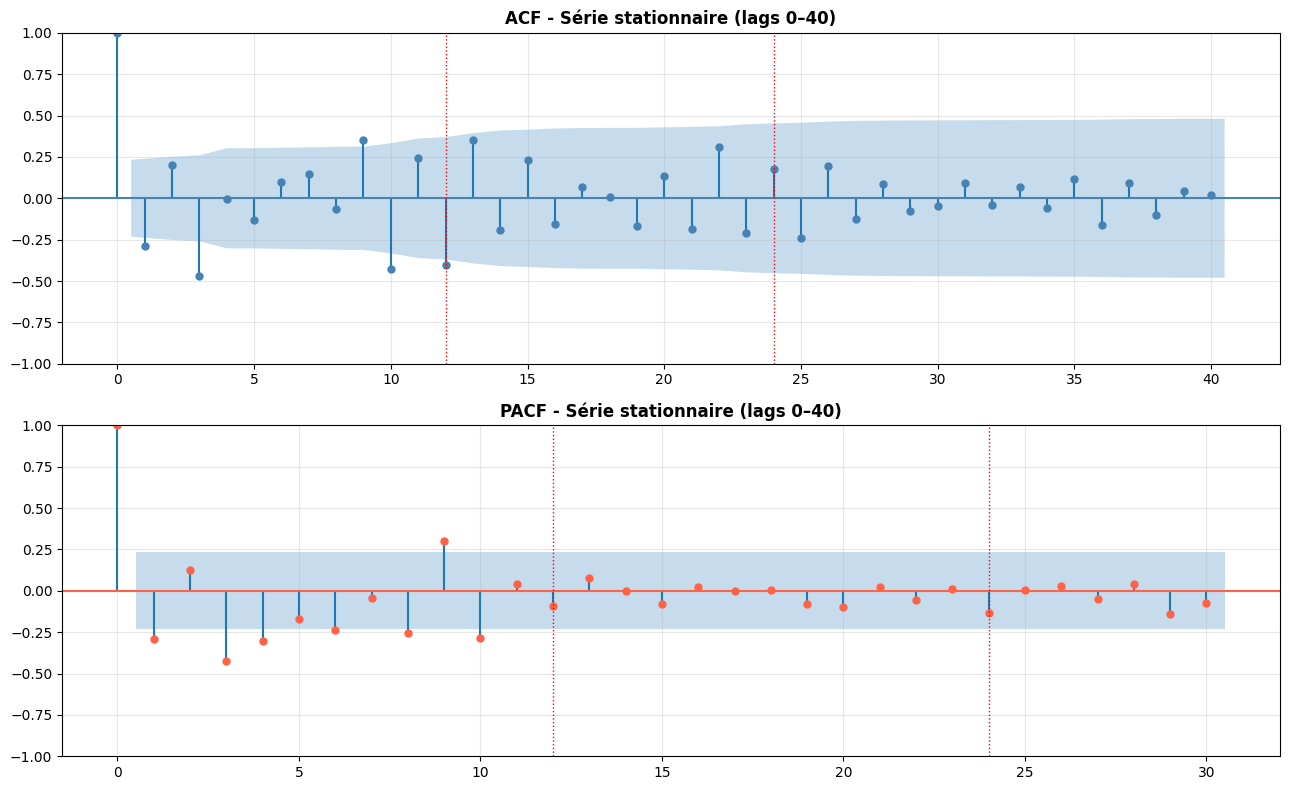

Lecture des corrélogrammes :
  • ACF  : coupure nette → composante MA ; décroissance lente → composante AR
  • PACF : coupure nette → composante AR
  • Pics aux lags 12, 24 → saisonnalité d'ordre s=12 confirmée


In [51]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

plot_acf(serie_stationnaire.dropna(),  lags=40, ax=axes[0], color="steelblue", alpha=0.05)
axes[0].set_title("ACF - Série stationnaire (lags 0–40)", fontsize=12, fontweight="bold")
axes[0].axvline(12, color="red", linestyle=":", linewidth=1, label="lag 12")
axes[0].axvline(24, color="red", linestyle=":", linewidth=1, label="lag 24")

plot_pacf(serie_stationnaire.dropna(), lags=30, ax=axes[1], color="tomato",    alpha=0.05)
axes[1].set_title("PACF - Série stationnaire (lags 0–40)", fontsize=12, fontweight="bold")
axes[1].axvline(12, color="red", linestyle=":", linewidth=1)
axes[1].axvline(24, color="red", linestyle=":", linewidth=1)

plt.tight_layout()
plt.show()

print("""Lecture des corrélogrammes :
  • ACF  : coupure nette → composante MA ; décroissance lente → composante AR
  • PACF : coupure nette → composante AR
  • Pics aux lags 12, 24 → saisonnalité d'ordre s=12 confirmée""")


## Étape 6 - Méthode de Box-Jenkins : SARIMA
### Modèle SARIMA(p, d, q)(P, D, Q)[s]
- **d=1, D=1, s=12** (déterminé à l'étape 4)  
- On cherche les meilleurs **(p, q, P, Q)** par grille AIC


In [45]:
# Recherche par grille AIC
p_vals = range(0, 3)
q_vals = range(0, 3)
P_vals = range(0, 2)
Q_vals = range(0, 2)

best_aic   = np.inf
best_order = None
resultats  = []

serie_log_train = np.log(train["Sales"])

print("Recherche en cours...")
for p, q, P, Q in itertools.product(p_vals, q_vals, P_vals, Q_vals):
    try:
        model = SARIMAX(serie_log_train,
                        order=(p, 1, q),
                        seasonal_order=(P, 1, Q, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        res = model.fit(disp=False)
        resultats.append({"p":p,"d":1,"q":q,"P":P,"D":1,"Q":Q,"AIC":round(res.aic,2)})
        if res.aic < best_aic:
            best_aic   = res.aic
            best_order = (p, q, P, Q)
    except:
        pass

df_aic = pd.DataFrame(resultats).sort_values("AIC").reset_index(drop=True)
print("Meilleur modele : SARIMA(%d,1,%d)(%d,1,%d)[12]" % (best_order[0],best_order[1],best_order[2],best_order[3]))
print("AIC =", round(best_aic, 2))
print("Top 5 modeles :")
df_aic.head()

Recherche en cours...
Meilleur modele : SARIMA(1,1,1)(1,1,1)[12]
AIC = -248.98
Top 5 modeles :


,p,d,q,P,D,Q,AIC
0,1,1,1,1,1,1,-248.98
1,0,1,2,1,1,0,-248.81
2,2,1,2,0,1,0,-248.57
3,1,1,0,0,1,0,-248.11
4,1,1,2,0,1,0,-247.36


In [46]:
# ── Estimation du meilleur modèle ────────────────────────────────────────────
p, q, P, Q = best_order

model_final = SARIMAX(serie_log_train,
                      order=(p, 1, q),
                      seasonal_order=(P, 1, Q, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

result = model_final.fit(disp=False)
print(result.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 129.492
Date:                            Sat, 09 May 2026   AIC                           -248.984
Time:                                    20:43:07   BIC                           -238.769
Sample:                                01-01-1960   HQIC                          -245.014
                                     - 12-01-1966                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4296      0.136      3.153      0.002       0.163       0.697
ma.L1         -1.0000    200.422   

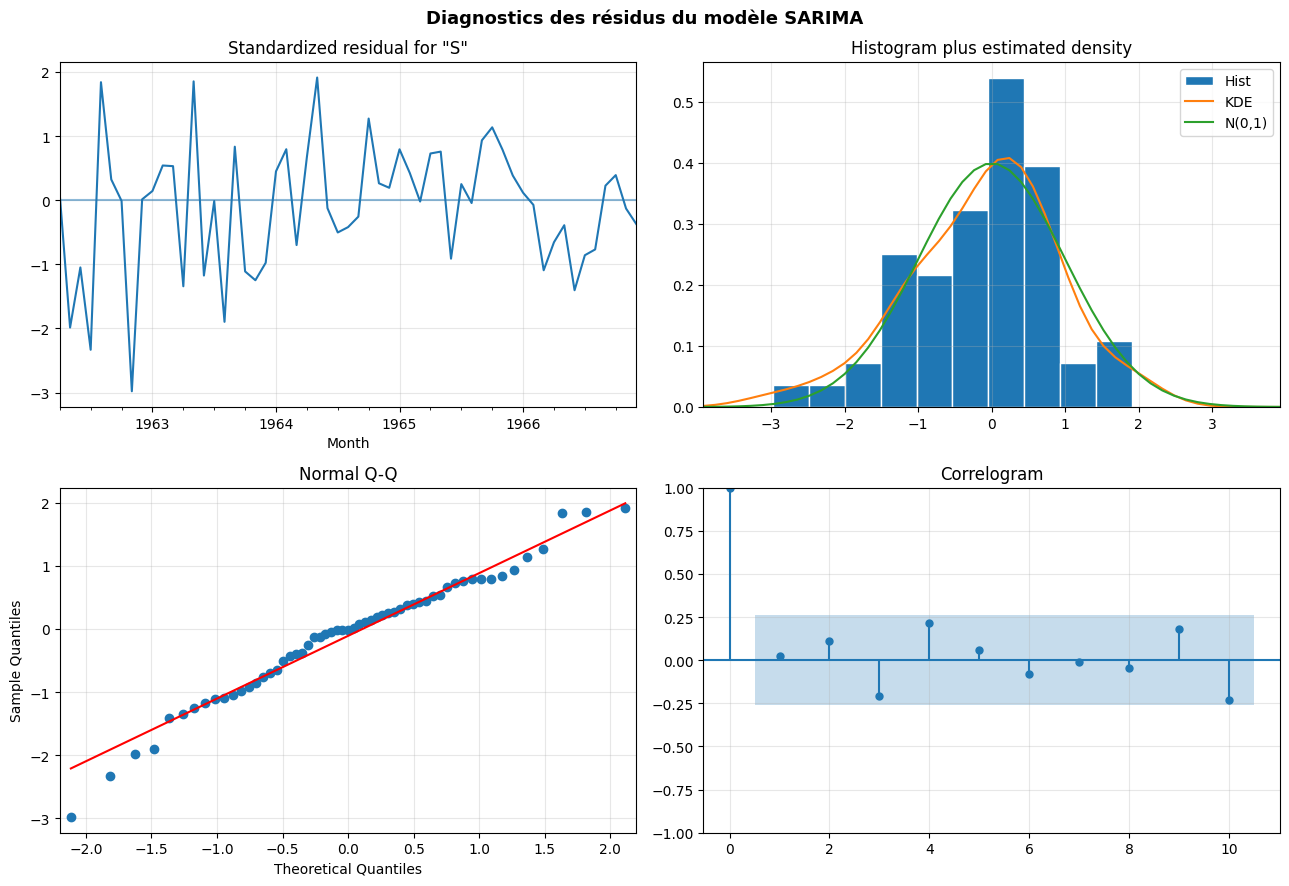

Vérifications :
  • Résidus ~ bruit blanc : pas de structure visible
  • Histogramme ~ N(0,1)
  • QQ-plot : points alignés sur la diagonale
  • ACF résidus : pas de pic significatif


In [47]:
# ── Validation des résidus ────────────────────────────────────────────────────
fig = result.plot_diagnostics(figsize=(13, 9))
fig.suptitle("Diagnostics des résidus du modèle SARIMA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("diagnostics_residus.png", dpi=150)
plt.show()

print("""Vérifications :
  • Résidus ~ bruit blanc : pas de structure visible
  • Histogramme ~ N(0,1)
  • QQ-plot : points alignés sur la diagonale
  • ACF résidus : pas de pic significatif""")


## Étape 7 — Prévision sur l'échantillon de validation

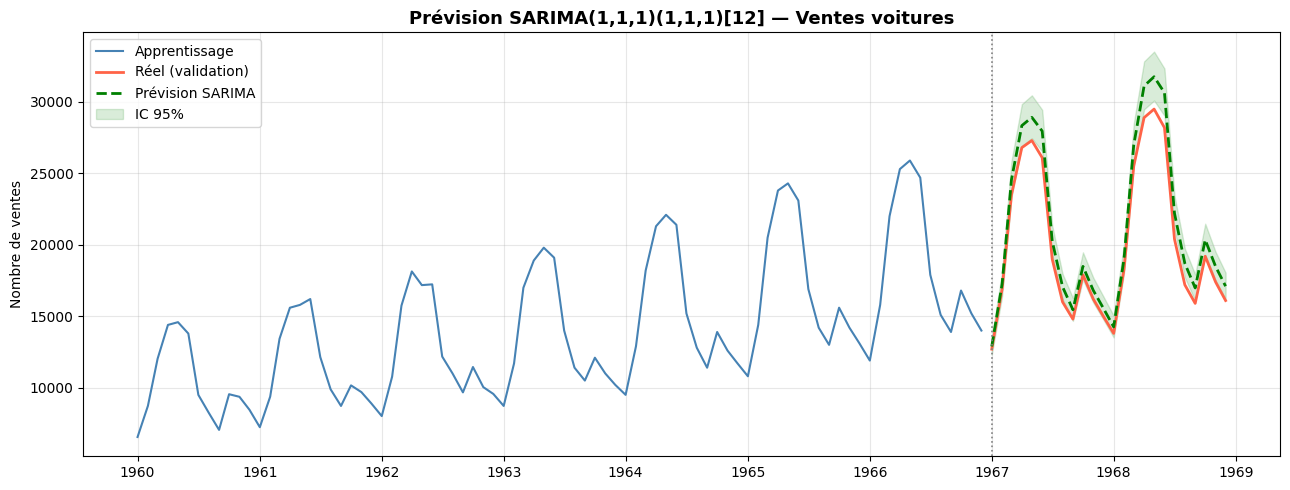

In [48]:
# ── Prévision 24 mois (sur l'échantillon test) ───────────────────────────────
forecast_log = result.get_forecast(steps=n_test)
pred_log     = forecast_log.predicted_mean
ci_log       = forecast_log.conf_int(alpha=0.05)

# Retour à l'échelle originale (exp)
pred   = np.exp(pred_log)
ci_low = np.exp(ci_log.iloc[:, 0])
ci_up  = np.exp(ci_log.iloc[:, 1])

pred.index   = test.index
ci_low.index = test.index
ci_up.index  = test.index

# Visualisation
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train["Sales"], color="steelblue", label="Apprentissage")
ax.plot(test.index,  test["Sales"],  color="tomato",    label="Réel (validation)", linewidth=2)
ax.plot(pred.index,  pred,           color="green",     label="Prévision SARIMA",  linewidth=2, linestyle="--")
ax.fill_between(pred.index, ci_low, ci_up, color="green", alpha=0.15, label="IC 95%")
ax.axvline(test.index[0], color="gray", linestyle=":", linewidth=1.2)
ax.set_title(f"Prévision SARIMA({p},1,{q})({P},1,{Q})[12] — Ventes voitures",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Nombre de ventes")
plt.legend()
plt.tight_layout()
plt.savefig("prevision.png", dpi=150)
plt.show()


## Étape 8 — Évaluation des performances

In [49]:
# ── Métriques de performance ─────────────────────────────────────────────────
y_true = test["Sales"].values
y_pred = pred.values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("="*45)
print(f" Évaluation sur l'échantillon de validation")
print("="*45)
print(f" MAE  (Erreur absolue moyenne)   : {mae:>10.0f}")
print(f" RMSE (Racine erreur quadratique) : {rmse:>10.0f}")
print(f" MAPE (Erreur relative moyenne)   : {mape:>9.2f}%")
print("="*45)

if mape < 10:
    print("Excellent : MAPE < 10%")
elif mape < 20:
    print("Bon : MAPE entre 10% et 20%")
else:
    print("MAPE > 20% — envisager d'autres modèles")


 Évaluation sur l'échantillon de validation
 MAE  (Erreur absolue moyenne)   :       1191
 RMSE (Racine erreur quadratique) :       1339
 MAPE (Erreur relative moyenne)   :      5.64%
Excellent : MAPE < 10%


In [50]:
# ── Tableau comparatif valeurs réelles vs prévisions ─────────────────────────
df_eval = pd.DataFrame({
    "Date"       : test.index.strftime("%b %Y"),
    "Réel"       : y_true.astype(int),
    "Prévision"  : y_pred.round(0).astype(int),
    "Erreur abs" : np.abs(y_true - y_pred).round(0).astype(int),
    "Erreur (%)" : (np.abs(y_true - y_pred) / y_true * 100).round(2)
})
df_eval.set_index("Date", inplace=True)
print(df_eval.to_string())


           Réel  Prévision  Erreur abs  Erreur (%)
Date                                              
Jan 1967  12700      12890         190        1.49
Feb 1967  16900      17255         355        2.10
Mar 1967  23500      24559        1059        4.50
Apr 1967  26800      28342        1542        5.75
May 1967  27300      28922        1622        5.94
Jun 1967  26100      27960        1860        7.13
Jul 1967  19000      20265        1265        6.66
Aug 1967  16000      17058        1058        6.61
Sep 1967  14800      15454         654        4.42
Oct 1967  17900      18490         590        3.30
Nov 1967  16200      16807         607        3.74
Dec 1967  15000      15565         565        3.77
Jan 1968  13800      14256         456        3.30
Feb 1968  18300      19034         734        4.01
Mar 1968  25500      26982        1482        5.81
Apr 1968  28900      31114        2214        7.66
May 1968  29500      31763        2263        7.67
Jun 1968  28200      30640     